In [ ]:
# =============================================================================
# MIT License
#
# Copyright (c) 2025 Jason Coleman
# UF MBI Microscopy Core / NeuroMicroscopy Co-op
# University of Florida
# jcoleman@ufl.edu
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.
# =============================================================================

# Notebook: image_hist&qc_scanimage.ipynb
# Version: 0.0.1
# Date: 2026-02-11

# Description:
#   Processing of 2 2-channel ScanImage TIFF ZT (timelapse) stacks to interactively plot and inspect image data
#       (e.g., histograms and quality-control metrics)


# Changelog:
#   0.0.1 (2026-02-11) – Modified from get_tif_info_scanimage.ipynb
  
# NOTE: This code is intended for research and educational use.
# Please cite or acknowledge the UF MBI Microscopy Core where appropriate.

# **License:** MIT  
# © 2026 Jason Coleman, UF MBI Microscopy Core / NeuroMicroscopy Co-op  
# University of Florida — jcoleman@ufl.edu


In [180]:
# Import ScanImage tif files (single-file)

# Works for ZT-, T-, Z- stacks

import numpy as np
import os
from pathlib import Path
import json
import socket
import tifffile # !pip install tifffile
import platform
import re
from datetime import datetime
import matplotlib.pyplot as plt

import pandas as pd

# Path to your ScanImage stack (replace 'text' with your directory
path = '/Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling/ZT20 TIFs'

# Name of the TIF file to import
# tif_filename1 = 'ZT20_25x_930_t0_area1_00001.tif' #'ZT20_25x_930_t5_area1_00001.tif'
tif_filename2 = 'ZT20_25x_1100_t0_area4_00001.tif' #'ZT20_25x_1100_t5_area1_00001.tif'
tif_filename1 = 'ZT20_25x_930_t0_area4_00001.tif'
# tif_filename2 = 'ZT20_25x_1100_t5_area1_00001.tif'

tif_file1 = os.path.join(
    path, 
    tif_filename1
)
tif_file2 = os.path.join(
    path, 
    tif_filename2
)

tif_data1 = tifffile.imread(tif_file1)
tif_data2 = tifffile.imread(tif_file2)

print(f'Pathname: {path}')
print(f'Filenames: {tif_filename1} | {tif_filename2}')
print(f'File1 shape: (e.g. Z, T, C, Y, X): {tif_data1.shape}')
print(f'File2 shape: (e.g. Z, T, C, Y, X): {tif_data2.shape}')

# NEXT STEPS - Run the next cell for 2-channel ZT data OR skip it and run the one after for T data


Pathname: /Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling/ZT20 TIFs
Filenames: ZT20_25x_930_t0_area4_00001.tif | ZT20_25x_1100_t0_area4_00001.tif
File1 shape: (e.g. Z, T, C, Y, X): (13, 20, 2, 512, 512)
File2 shape: (e.g. Z, T, C, Y, X): (13, 20, 2, 512, 512)


In [181]:
# Read in Channel1 (green) and Channel2 (red) from 2 TIF files, recombine for green-red
import tifffile as tiff
import numpy as np

def load_ztcyx(path):
    data = tiff.imread(path)
    if data.ndim != 5:
        raise ValueError(f"Expected 5D (Z,T,C,Y,X) but got {data.shape}")
    return data

def recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=None):
    if tif1_ch1.shape != tif2_ch2.shape:
        msg = (
            f"SKIP: shape mismatch "
            f"Ch1 {tif1_ch1.shape} vs Ch2 {tif2_ch2.shape}"
        )
        if filename:
            msg += f" | file={filename}"
        print(msg)
        return None  # sentinel → skip downstream

    return np.stack([tif1_ch1, tif2_ch2], axis=2)  # (Z,T,2,Y,X)

tif1 = load_ztcyx(tif_file1)  # (Z,T,C,Y,X)
tif2 = load_ztcyx(tif_file2)  # (Z,T,C,Y,X)

# Extract desired channels
tif1_ch1 = tif1[0:, :, 0, :, :]   # (Z,T,Y,X)
tif2_ch2 = tif2[:, :, 1, :, :]   # (Z,T,Y,X)
# tif2_ch2 = tif2[0:11, :, 1, :, :]   # mismatch for ch1-ch2 Z-correlation tests (Z,T,Y,X)

# # Validate shape compatibility
# if tif1_ch1.shape != tif2_ch2.shape:
#     raise ValueError(f"Shape mismatch: {tif1_ch1.shape} vs {tif2_ch2.shape}")

# # Recombine into new "tif_data" with 2 channels
# tif_data = np.stack([tif1_ch1, tif2_ch2], axis=2)  # (Z,T,C,Y,X)
# tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=tif_file1)

# if tif_data is None:
#     # Optionally log this somewhere
#     skipped_files.append(tif_file1)
#     skip_log.append({
#         "file_ch1": tif1_path,
#         "file_ch2": tif2_path,
#         "shape_ch1": tif1_ch1.shape,
#         "shape_ch2": tif2_ch2.shape,
#         "reason": "Z/T/Y/X mismatch"
#     })
#     return  # move to next file
skipped_files = []
skip_log = []
tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2)

if tif_data is None:
    skipped_files.append(path)
    skip_log.append({
        "file_ch1": tif_file1,
        "file_ch2": tif_file2,
        "shape_ch1": tif1_ch1.shape,
        "shape_ch2": tif2_ch2.shape,
        "reason": "Z/T/Y/X mismatch"
    })

    print(skipped_files)
    print(skip_log)
else:
    print("FUTURE: run_qc(tif_data)")

    # Now your existing QC code works as-is
    Z, T, C, Y, X = tif_data.shape

    print(f'Ch1 from {tif_filename1} + Ch2 from {tif_filename1} combined into single tif_data')

FUTURE: run_qc(tif_data)
Ch1 from ZT20_25x_930_t0_area4_00001.tif + Ch2 from ZT20_25x_930_t0_area4_00001.tif combined into single tif_data


In [160]:
# # UNCOMMENT AND RUN THIS CELL IF YOU HAVE "RAW" ZT data (e.g. (Z,T,C,Y,X))

# # Works for 2-channel tif_data with 5 dims (Z,T,C,Y,X)
# # Eg: ZT20_*.tif-type data
# # Extract channel 1 and channel 2 and reshape to (Z, Y, X)
# # Get T frames from the middle Z slice#
# zslice_middle = int(len(tif_data[0])/2)
# zsliceNum = zslice_middle

# channel_1_data = tif_data[zsliceNum, :, 0, :, :]  # shape: (33, 512, 512)
# channel_2_data = tif_data[zsliceNum, :, 1, :, :]  # shape: (33, 512, 512)

# print(f"Channel 1   shape: {channel_1_data.shape}")
# print(f"Channel 2   shape: {channel_2_data.shape}")

# # Transpose to (Y, X, Z) if needed for your code
# channel_1_data = np.transpose(channel_1_data, (1, 2, 0))  # shape: (512, 512, 33)
# channel_2_data = np.transpose(channel_2_data, (1, 2, 0))  # shape: (512, 512, 33)

# print(f"Channel 1 reshape: {channel_1_data.shape}")
# print(f"Channel 2 reshape: {channel_2_data.shape}")

In [161]:
# # UNCOMMENT AND RUN THIS CELL IF YOU HAVE Z- or T-only data (e.g. (T,C,Y,X))

# # Works for 2-channel tif_data with 4 dims (T,C,Y,X)
# # Extract channel 1 and channel 2 and reshape to (Z, Y, X)
# # Eg: T1800_*.tif-type data
# channel_1_data = tif_data[:, 0, :, :]  # shape: (33, 512, 512)
# channel_2_data = tif_data[:, 1, :, :]  # shape: (33, 512, 512)

# print(f"Channel 1   shape: {channel_1_data.shape}")
# print(f"Channel 2   shape: {channel_2_data.shape}")

# # Transpose to (Y, X, Z) if needed for your code
# channel_1_data = np.transpose(channel_1_data, (1, 2, 0))  # shape: (512, 512, 33)
# channel_2_data = np.transpose(channel_2_data, (1, 2, 0))  # shape: (512, 512, 33)

# print(f"Channel 1 reshape: {channel_1_data.shape}")
# print(f"Channel 2 reshape: {channel_2_data.shape}")

In [162]:
# Average across T for every Z
    # (Eg for ZT20*.tif file, 20 T frames will be averaged into a single plane/2D image at each Z)
    # Calculate the average intensity for each Z-plane (17 total)
    # across all time frames (20 total) per plane.
    # Formula: Z_avg[i] = mean(Frames[i, 0:20])

    # Process: Z-Average Projection
    # Input:  (Z=17, T=20, Y, X)
    # Output: (Z=17, Y, X) 
    # Expression: Avg_Zi = Σ(T_0...T_19) / 20


tif_Zavg = tif_data.mean(axis=1)  # (Z, C, Y, X)
print(tif_Zavg.shape)

zslice_middle = int(len(tif_Zavg)/2)
zsliceNum = zslice_middle
print(f"Plot Z-slice#: {zsliceNum}")

(17, 2, 512, 512)
Plot Z-slice#: 8


In [163]:
# UNCOMMENT AND RUN THIS CELL IF YOU HAVE Z data averaged over T (e.g. (T,C,Y,X))
# use for Z T-avg'ed data (ie Avg_Zi = Σ(T_0...T_19) / 20)

channel_1_data = tif_Zavg[:, 0, :, :]  # shape: (33, 512, 512)
channel_2_data = tif_Zavg[:, 1, :, :]  # shape: (33, 512, 512)

print(f"Channel 1   shape: {channel_1_data.shape}")
print(f"Channel 2   shape: {channel_2_data.shape}")

# Transpose to (Y, X, Z) if needed for your code
channel_1_data = np.transpose(channel_1_data, (1, 2, 0))  # shape: (512, 512, 33)
channel_2_data = np.transpose(channel_2_data, (1, 2, 0))  # shape: (512, 512, 33)

print(f"Channel 1 reshape: {channel_1_data.shape}")
print(f"Channel 2 reshape: {channel_2_data.shape}")

zsliceNum
# zsliceNum = 10 # Optional value for plotting below, replaces the middle value from above

Channel 1   shape: (17, 512, 512)
Channel 2   shape: (17, 512, 512)
Channel 1 reshape: (512, 512, 17)
Channel 2 reshape: (512, 512, 17)


8

In [164]:
# # Sanity check the channels
# import matplotlib.pyplot as plt

# # if shape has T and Z, use frame and Zslice
# # frame = 5 #choose frame number 0-max (from frame# 0 to frame# MAX)
# # otherwise just use Zlice (or frame if a Tseries)
# slice = 5

# plt.figure()
# plt.imshow(channel_1_data[:,:,slice], cmap='gray')
# plt.title(f'Channel 1 (frame {slice} | Zslice {zsliceNum})')
# plt.show()

# plt.figure()
# plt.imshow(channel_2_data[:,:,slice], cmap='gray')
# plt.title(f'Channel 2 (frame {slice} | Zslice {zsliceNum})')
# plt.show()

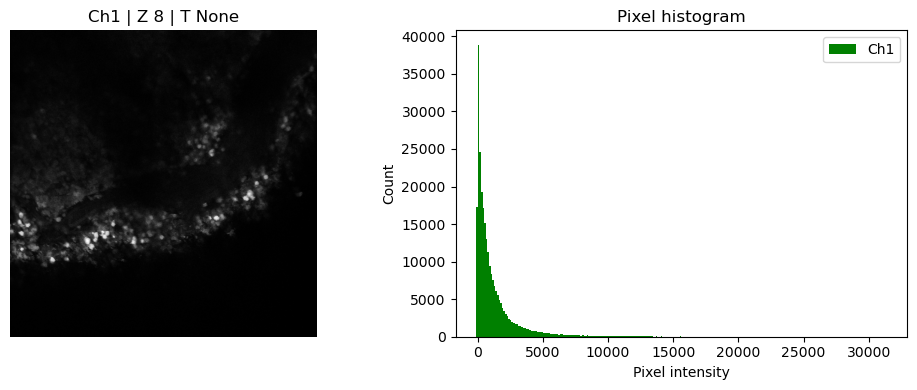

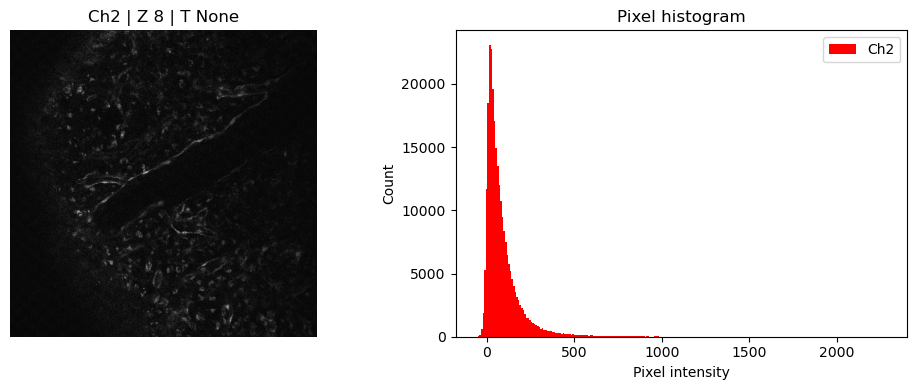

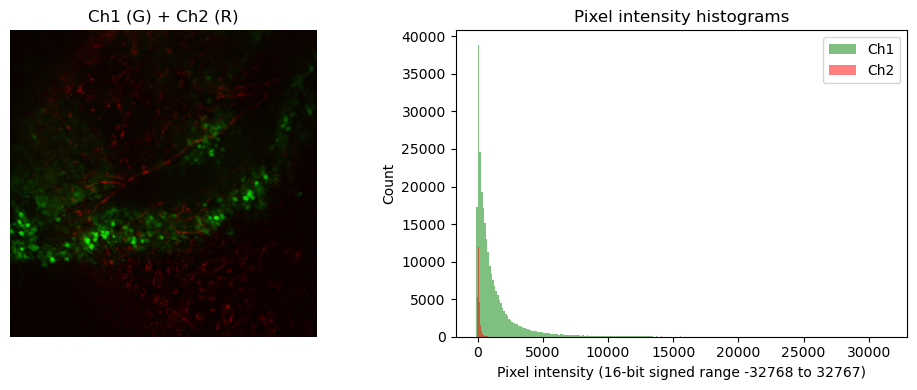

In [165]:
# Sanity check the channels - w/ histograms and ch1+ch2 overlay

# import numpy as np
# import matplotlib.pyplot as plt

def plot_slice_histogram(img, histcolor, zsliceNum=0, frame=None, channel='signal'):
    # img = channel_1_data[:, :, frame]
    pixels = img.ravel()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Image
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'{channel} | Z {zsliceNum} | T {frame}')
    axes[0].axis('off')
    
    # Histogram
    # axes[1].hist(pixels, bins=256, density=True, color=histcolor)
    axes[1].hist(pixels, bins=256, density=False, color=histcolor, label=channel)
    axes[1].set_xlabel('Pixel intensity')
    # axes[1].set_ylabel('Probability density')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel histogram')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_overlay_and_hist(img1, img2, zsliceNum=0, frame=None,
                          bins=256, alpha=0.5, Saturation=32767):
    """
    img1, img2: (Y, X) arrays for channel 1 and channel 2
    """

    # Build RGB overlay (normalize for display only)
    def norm(im):
        im = im.astype(float)
        return (im - im.min()) / (im.max() - im.min() + 1e-9)

    rgb = np.zeros((*img1.shape, 3))
    rgb[..., 1] = norm(img1)   # green
    rgb[..., 0] = norm(img2)   # red

    # Flatten pixels
    p1 = img1.ravel()
    p2 = img2.ravel()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # ---- Overlay image ----
    axes[0].imshow(rgb)
    title = "Ch1 (G) + Ch2 (R)"
    if zsliceNum is not None and frame is not None:
        title += f" | Z {zsliceNum} | T {frame}"
    axes[0].set_title(title)
    axes[0].axis('off')

    # ---- Overlaid histograms ----
    axes[1].hist(p1, bins=bins, density=False,
                 color='green', alpha=alpha, label='Ch1')
    axes[1].hist(p2, bins=bins, density=False,
                 color='red', alpha=alpha, label='Ch2')

    axes[1].set_xlabel(f'Pixel intensity (16-bit signed range -32768 to 32767)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel intensity histograms')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def preprocess_background(img, bg_pctle=5, norm_pctle=99):
    # perform background subtraction and normalization
    # 1. Keep raw int16 data untouched
    img_raw = img
    
    # 2. Background subtract (robust)
    bg = np.percentile(img_raw, bg_pctle)
    img_bg = img_raw - bg
    
    # 3. (Optional) Normalize to reference
    img_norm = img_bg / np.percentile(img_bg, norm_pctle)

    return img_bg, img_norm

# run the functions here
# frame = 5 # select T frame
# img_chan1 = channel_1_data[:, :, frame]
# img_chan2 = channel_2_data[:, :, frame]

# Need to distinguish Z, T etc explicitlu hehre
img_chan1 = channel_1_data[:, :, zsliceNum]
img_chan2 = channel_2_data[:, :, zsliceNum]

img_chan1_background, img_chan1_normalized = preprocess_background(img_chan1, bg_pctle=5, norm_pctle=99)
img_chan2_background, img_chan2_normalized = preprocess_background(img_chan2, bg_pctle=5, norm_pctle=99)

plot_slice_histogram(img_chan1_background, 'green', zsliceNum, channel='Ch1')
plot_slice_histogram(img_chan2_background, 'red', zsliceNum, channel='Ch2')
plot_overlay_and_hist(img_chan1_background, img_chan2_background,
                      zsliceNum=zsliceNum, frame=None)


In [166]:
print(tif_data.dtype)
print("min:", tif_data.min())
print("max:", tif_data.max())

print(tif_Zavg.dtype)
print("min:", tif_Zavg.min())
print("max:", tif_Zavg.max())

int16
min: -3023
max: 32767
float64
min: -127.65
max: 32767.0


In [167]:
# # Image QC and basic background subtraction options

# med, iqr, sat = [], [], []

# Z, T, C, Y, X = tif_data.shape

# Z, T, C, Y, X


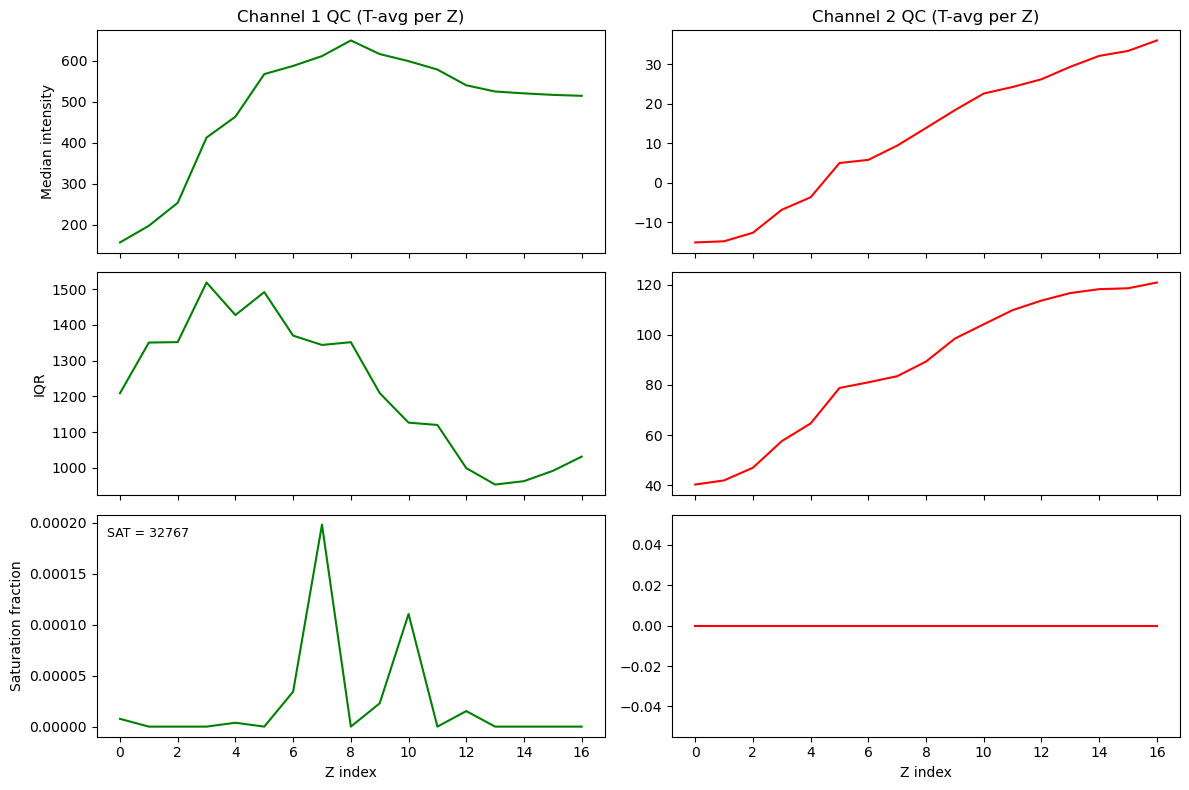

In [168]:
# # for z in range(Z):
# #     img = tif_data[z, :, 0, :, :].mean(axis=0)  # avg T, Ch1
# #     pixels = img.ravel()

# #     med.append(np.median(pixels))
# #     iqr.append(np.percentile(pixels, 75) - np.percentile(pixels, 25))
# #     sat.append(np.mean(pixels >= 32767))

# # plt.figure(figsize=(10,12))
# # plt.subplot(3,1,1)
# # plt.title('Channel 1 QC')
# # plt.plot(med)
# # plt.ylabel("Median intensity")

# # plt.subplot(3,1,2)
# # plt.plot(iqr)
# # plt.ylabel("IQR")

# # plt.subplot(3,1,3)
# # plt.plot(sat)
# # plt.ylabel("Saturation fraction")
# # plt.xlabel("Z index")

# # plt.tight_layout()
# # plt.show()

# SAT = 32767
# Z, T, C, Y, X = tif_data.shape

def qc_per_z(channel_idx):
    med = np.zeros(Z)
    iqr = np.zeros(Z)
    sat = np.zeros(Z)

    for z in range(Z):
        img = tif_data[z, :, channel_idx, :, :].mean(axis=0)  # T-avg -> (Y,X)
        px = img.ravel()

        med[z] = np.median(px)
        iqr[z] = np.percentile(px, 75) - np.percentile(px, 25)
        sat[z] = np.mean(px >= SAT)

    return med, iqr, sat

med1, iqr1, sat1 = qc_per_z(0)  # Ch1
med2, iqr2, sat2 = qc_per_z(1)  # Ch2

fig, ax = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

# Row 1: Median
ax[0,0].plot(med1, color='green'); ax[0,0].set_title("Channel 1 QC (T-avg per Z)"); ax[0,0].set_ylabel("Median intensity")
ax[0,1].plot(med2, color='red'); ax[0,1].set_title("Channel 2 QC (T-avg per Z)")
# ax[0,0].set_xlim(xmin, xmax)
# ax[i,j].set_ylim(ymin, ymax)

# Row 2: IQR
ax[1,0].plot(iqr1, color='green'); ax[1,0].set_ylabel("IQR")
ax[1,1].plot(iqr2, color='red')

# Row 3: Saturation fraction
ax[2,0].plot(sat1, color='green'); ax[2,0].set_ylabel("Saturation fraction"); ax[2,0].set_xlabel("Z index")
ax[2,0].text(0.02, 0.9, "SAT = 32767", transform=ax[2,0].transAxes, fontsize=9)
ax[2,1].plot(sat2, color='red'); ax[2,1].set_xlabel("Z index")

plt.tight_layout()
plt.show()

# After plotting
for row in range(3):
    ymins = []
    ymaxs = []
    for col in range(2):
        ymins.append(ax[row, col].get_ylim()[0])
        ymaxs.append(ax[row, col].get_ylim()[1])
    ymin, ymax = min(ymins), max(ymaxs)
    for col in range(2):
        ax[row, col].set_ylim(ymin, ymax)


In [169]:
"""
Notes / knobs you’ll likely tweak

If your Ch2 medians routinely exceed 12k (bright dyes / high gain), bump:

ylim_med_ch2 = (0, 20000) (or 30000)

If your IQR is usually >2000 (dense structure), bump:

ylim_iqr_ch2 = (0, 4000)

If you want the guideline lines to be bands instead of individual lines (shaded zones), I can swap to axhspan().
"""
# QC thresholds (recap, encoded once)
# ---- QC thresholds (int16 ScanImage-style) ----
SAT = 32767

# Median (intensity)
MED_DIM = 500
MED_GOOD_LO, MED_GOOD_HI = 1000, 8000
MED_HOT_HI = 15000

# IQR (contrast / structure)
IQR_LOW = 50
IQR_GOOD_LO, IQR_GOOD_HI = 100, 800
IQR_CEIL = 2000

# Saturation fraction
SAT_WARN = 0.01     # 1%
SAT_BAD  = 0.05     # 5%


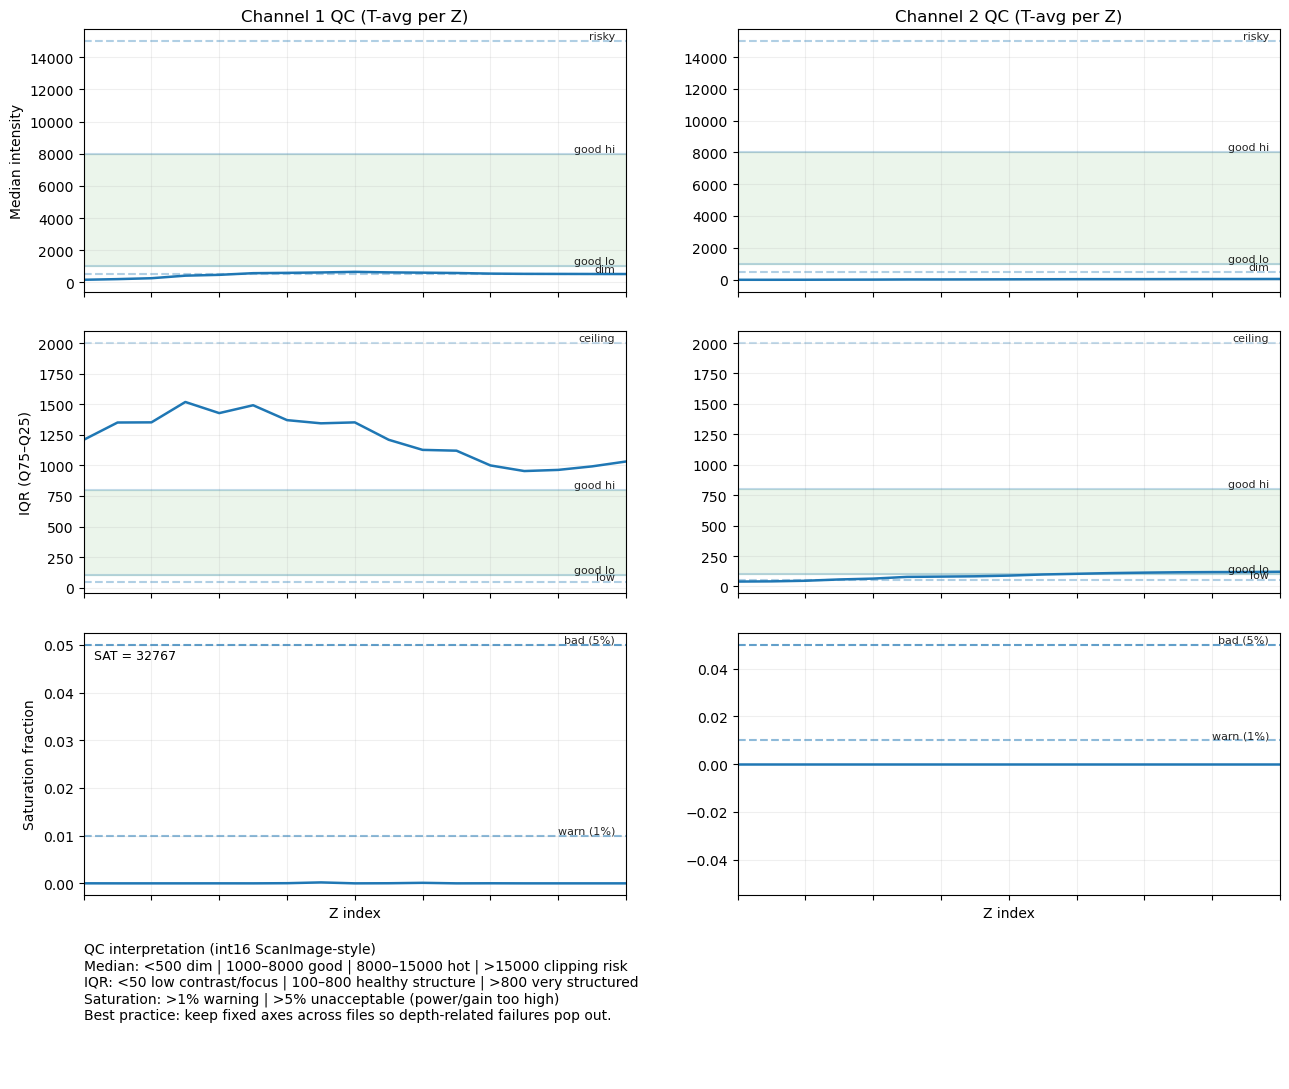

In [170]:
# Helper for guide lines
def add_guides(a, guides):
    """
    guides: list of (y, linestyle, alpha, label)
    """
    for y, ls, alpha, label in guides:
        a.axhline(y, ls=ls, alpha=alpha)
        if label:
            a.text(
                0.98, y, label,
                transform=a.get_yaxis_transform(),
                ha="right", va="bottom",
                fontsize=8, alpha=0.85
            )

# Figure: 3 QC rows + explanation row
fig, ax = plt.subplots(
    4, 2,
    figsize=(13, 11),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1, 1, 0.55]}
)

# Row 1 — Median intensity
ax[0,0].plot(med1, lw=1.8)
ax[0,1].plot(med2, lw=1.8)

ax[0,0].set_title("Channel 1 QC (T-avg per Z)")
ax[0,1].set_title("Channel 2 QC (T-avg per Z)")
ax[0,0].set_ylabel("Median intensity")

median_guides = [
    (MED_DIM, "--", 0.35, "dim"),
    (MED_GOOD_LO, "-", 0.25, "good lo"),
    (MED_GOOD_HI, "-", 0.25, "good hi"),
    (MED_HOT_HI, "--", 0.35, "risky"),
]
# Good median band
ax[0,0].axhspan(
    MED_GOOD_LO, MED_GOOD_HI,
    color='green', alpha=0.08, zorder=0
)
ax[0,1].axhspan(
    MED_GOOD_LO, MED_GOOD_HI,
    color='green', alpha=0.08, zorder=0
)


add_guides(ax[0,0], median_guides)
add_guides(ax[0,1], median_guides)

# ax[0,0].set_ylim(0, 12000)
# ax[0,1].set_ylim(0, 12000)


# Row 2 — IQR
ax[1,0].plot(iqr1, lw=1.8)
ax[1,1].plot(iqr2, lw=1.8)

ax[1,0].set_ylabel("IQR (Q75–Q25)")

iqr_guides = [
    (IQR_LOW, "--", 0.35, "low"),
    (IQR_GOOD_LO, "-", 0.25, "good lo"),
    (IQR_GOOD_HI, "-", 0.25, "good hi"),
    (IQR_CEIL, "--", 0.25, "ceiling"),
]
ax[1,0].axhspan(
    IQR_GOOD_LO, IQR_GOOD_HI,
    color='green', alpha=0.08, zorder=0
)
ax[1,1].axhspan(
    IQR_GOOD_LO, IQR_GOOD_HI,
    color='green', alpha=0.08, zorder=0
)

add_guides(ax[1,0], iqr_guides)
add_guides(ax[1,1], iqr_guides)

# ax[1,0].set_ylim(0, IQR_CEIL)
# ax[1,1].set_ylim(0, IQR_CEIL)


# Row 3 — Saturation fraction (critical)
ax[2,0].plot(sat1, lw=1.8)
ax[2,1].plot(sat2, lw=1.8)

ax[2,0].set_ylabel("Saturation fraction")
ax[2,0].text(
    0.02, 0.9, f"SAT = {SAT}",
    transform=ax[2,0].transAxes,
    fontsize=9
)

# Warning / failure lines
sat_guides = [
    (SAT_WARN, "--", 0.5, "warn (1%)"),
    (SAT_BAD,  "--", 0.7, "bad (5%)"),
]

add_guides(ax[2,0], sat_guides)
add_guides(ax[2,1], sat_guides)

# ax[2,0].set_ylim(0, 0.1)
# ax[2,1].set_ylim(0, 0.1)

# Shared X, grids, polish
xmax = Z - 1
for a in ax[0:3, :].flat:
    a.set_xlim(0, xmax)
    a.grid(True, alpha=0.2)

ax[2,0].set_xlabel("Z index")
ax[2,1].set_xlabel("Z index")

# Row 4 — Explanation panel (no axes)
for c in range(2):
    ax[3,c].axis("off")

explain = (
    "QC interpretation (int16 ScanImage-style)\n"
    "Median: <500 dim | 1000–8000 good | 8000–15000 hot | >15000 clipping risk\n"
    "IQR: <50 low contrast/focus | 100–800 healthy structure | >800 very structured\n"
    "Saturation: >1% warning | >5% unacceptable (power/gain too high)\n"
    "Best practice: keep fixed axes across files so depth-related failures pop out."
)

ax[3,0].text(
    0.0, 0.95, explain,
    ha="left", va="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [171]:
"""
How to interpret these (especially for tdTomato)

For a sparse red channel:

If P5 rises with Z but P99 and top_mean are flat-ish
→ baseline/offset drift or depth-dependent background dominates.

If P99/top_mean rise with Z too
→ true depth-dependent detection/power or real biological increase.

If P99−P5 rises but bright_frac stays constant
→ objects get brighter but occupy similar area.

If bright_frac rises
→ more red-positive area at those Zs (could be structure density or focus band).

If you want bright_frac explicitly plotted, add a 5th row or swap it into row 3.

Here’s a drop-in upgrade that gives you the “sparse-channel aware” QC set without changing your data model.

What we’ll add (per Z, per channel)

Baseline / offset
p5 (or p10)

Signal-sensitive
p50 (median)
p95, p99

Contrast
dr = p99 - p5

Clipping
sat (>= SAT)
near_sat (>= SAT - margin)

Sparse-aware
top_mean: mean of top q% pixels (e.g., 0.5% brightest)
bright_frac: fraction of pixels above an adaptive threshold (e.g., > p99)

That last pair is the big win for tdTomato.
"""

# import numpy as np
# import matplotlib.pyplot as plt

SAT = 32767

def qc_per_z_extended(channel_idx, *,
                      p_lo=5, p_hi1=95, p_hi2=99,
                      top_frac=0.005,          # top 0.5%
                      near_sat_margin=500,      # counts below SAT
                      bright_thresh_mode="p99"  # "p99" or "p995" or numeric
                     ):
    """
    tif_data expected shape: (Z, T, C, Y, X)
    Returns dict of per-Z metrics.
    """
    med = np.zeros(Z)
    iqr = np.zeros(Z)
    sat = np.zeros(Z)

    p5 = np.zeros(Z)
    p50 = np.zeros(Z)
    p95 = np.zeros(Z)
    p99 = np.zeros(Z)
    dr = np.zeros(Z)

    near_sat = np.zeros(Z)

    top_mean = np.zeros(Z)
    bright_frac = np.zeros(Z)

    for z in range(Z):
        img = tif_data[z, :, channel_idx, :, :].mean(axis=0)  # (Y,X)
        px = img.ravel()

        # percentiles
        p5[z]  = np.percentile(px, p_lo)
        p50[z] = np.percentile(px, 50)
        p95[z] = np.percentile(px, p_hi1)
        p99[z] = np.percentile(px, p_hi2)
        dr[z]  = p99[z] - p5[z]

        # legacy metrics (keep)
        med[z] = p50[z]
        iqr[z] = np.percentile(px, 75) - np.percentile(px, 25)
        sat[z] = np.mean(px >= SAT)
        near_sat[z] = np.mean(px >= (SAT - near_sat_margin))

        # top fraction mean (sparse-signal proxy)
        k = max(1, int(np.floor(top_frac * px.size)))
        # partition is faster than full sort
        topk = np.partition(px, -k)[-k:]
        top_mean[z] = np.mean(topk)

        # bright fraction above threshold
        if isinstance(bright_thresh_mode, (int, float)):
            thr = bright_thresh_mode
        else:
            if bright_thresh_mode == "p99":
                thr = p99[z]
            elif bright_thresh_mode == "p995":
                thr = np.percentile(px, 99.5)
            elif bright_thresh_mode == "p999":
                thr = np.percentile(px, 99.9)
            else:
                thr = p99[z]
        bright_frac[z] = np.mean(px > thr)

    return {
        "p5": p5, "p50": p50, "p95": p95, "p99": p99,
        "dr": dr,
        "iqr": iqr,
        "sat": sat, "near_sat": near_sat,
        "top_mean": top_mean,
        "bright_frac": bright_frac,
    }

qc1 = qc_per_z_extended(0)  # Ch1
qc2 = qc_per_z_extended(1)  # Ch2


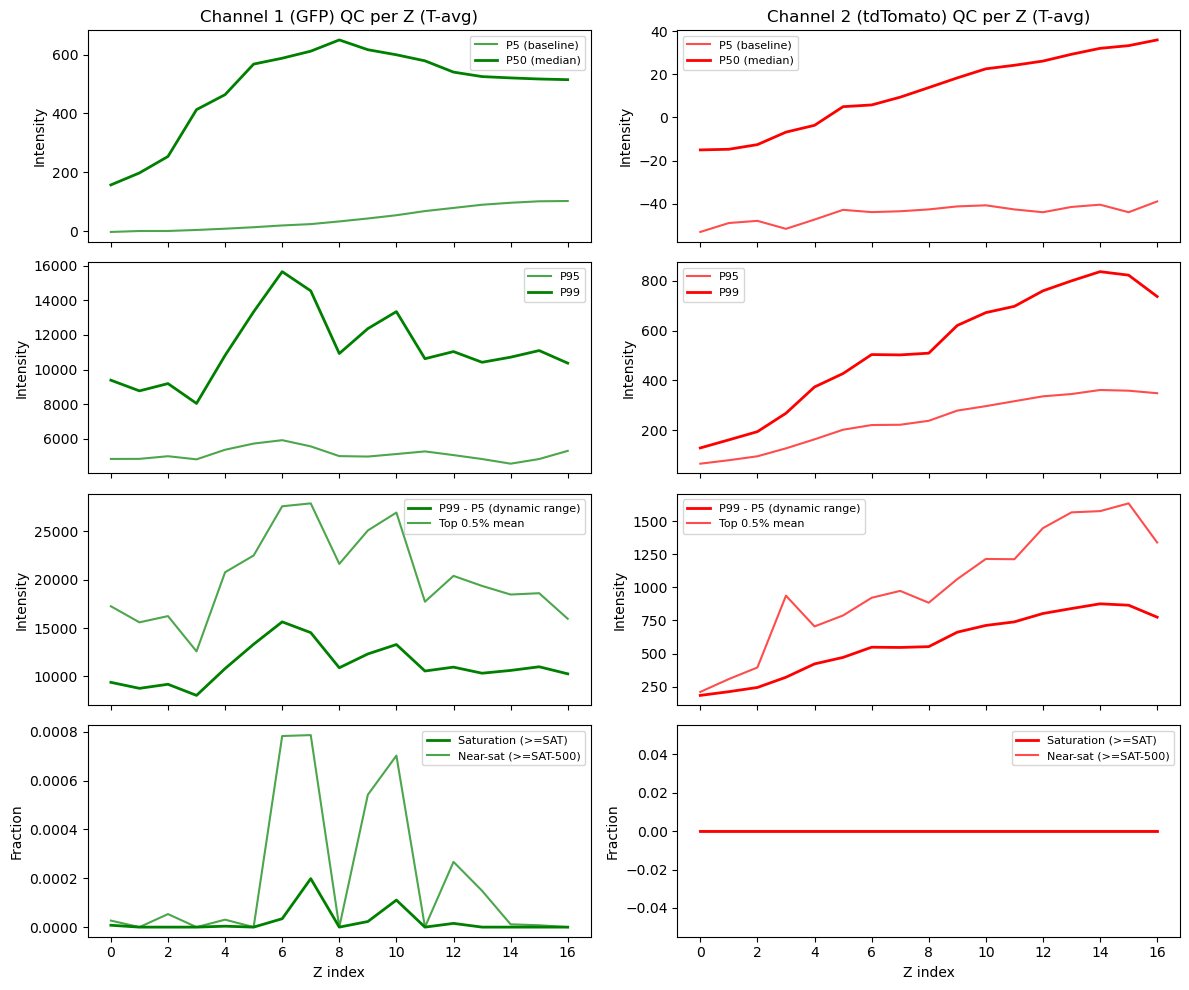

In [172]:
# Plotting: a “high-value” QC figure (4 rows × 2 cols)
# This replaces your 3×2 with something more informative for sparse channels.
fig, ax = plt.subplots(4, 2, figsize=(12, 10), sharex=True)

def plot_channel(col, qc, color, title):
    # Row 1: Baseline + central tendency
    ax[0, col].plot(qc["p5"],  color=color, alpha=0.7, label="P5 (baseline)")
    ax[0, col].plot(qc["p50"], color=color, lw=2, label="P50 (median)")
    ax[0, col].set_title(title)
    ax[0, col].set_ylabel("Intensity")
    ax[0, col].legend(fontsize=8)

    # Row 2: Signal-sensitive percentiles
    ax[1, col].plot(qc["p95"], color=color, alpha=0.7, label="P95")
    ax[1, col].plot(qc["p99"], color=color, lw=2, label="P99")
    ax[1, col].set_ylabel("Intensity")
    ax[1, col].legend(fontsize=8)

    # Row 3: Contrast + sparse-signal proxy
    ax[2, col].plot(qc["dr"],       color=color, lw=2, label="P99 - P5 (dynamic range)")
    ax[2, col].plot(qc["top_mean"], color=color, alpha=0.7, label="Top 0.5% mean")
    ax[2, col].set_ylabel("Intensity")
    ax[2, col].legend(fontsize=8)

    # Row 4: Clipping / saturation
    ax[3, col].plot(qc["sat"],      color=color, lw=2, label="Saturation (>=SAT)")
    ax[3, col].plot(qc["near_sat"], color=color, alpha=0.7, label="Near-sat (>=SAT-500)")
    ax[3, col].set_ylabel("Fraction")
    ax[3, col].set_xlabel("Z index")
    ax[3, col].legend(fontsize=8)

plot_channel(0, qc1, "green", "Channel 1 (GFP) QC per Z (T-avg)")
plot_channel(1, qc2, "red",   "Channel 2 (tdTomato) QC per Z (T-avg)")

plt.tight_layout()
plt.show()

# Match y-lims across channels for each row (like you already do)
for row in range(ax.shape[0]):
    ymins = [ax[row, 0].get_ylim()[0], ax[row, 1].get_ylim()[0]]
    ymaxs = [ax[row, 0].get_ylim()[1], ax[row, 1].get_ylim()[1]]
    ymin, ymax = min(ymins), max(ymaxs)
    ax[row, 0].set_ylim(ymin, ymax)
    ax[row, 1].set_ylim(ymin, ymax)


In [174]:
from skimage.filters import gaussian
# import numpy as np

def structural_proxy(img, sigma=6):
    im = img.astype(np.float32)
    im = gaussian(im, sigma=sigma, preserve_range=True)
    im = (im - im.mean()) / (im.std() + 1e-8)
    return im

def z_similarity_matrix(gfp_stack, tdt_stack):
    Z = gfp_stack.shape[0]
    sim = np.zeros((Z, Z))
    
    gfp_blur = np.array([structural_proxy(g) for g in gfp_stack])
    tdt_blur = np.array([structural_proxy(t) for t in tdt_stack])
    
    for i in range(Z):
        for j in range(Z):
            sim[i,j] = np.mean((gfp_blur[i] - tdt_blur[j])**2)
    
    return sim

# T-average each acquisition
zavg_930  = tif_data1.mean(axis=1)
zavg_1100 = tif_data2.mean(axis=1)
# Select relevant channels
gfp_930  = zavg_930[0:17, 0, :, :]
tdt_1100 = zavg_1100[:, 1, :, :]

sim = z_similarity_matrix(gfp_930, tdt_1100)

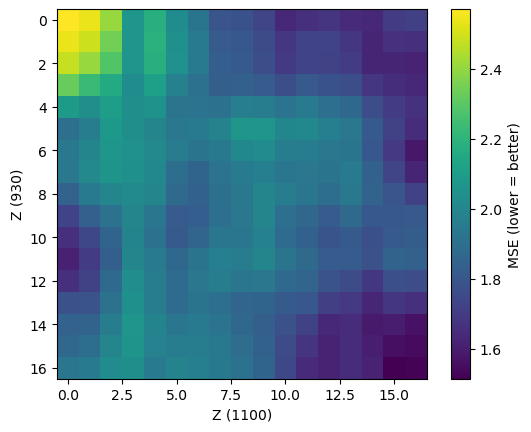

In [175]:
plt.imshow(sim, cmap='viridis')
plt.colorbar(label="MSE (lower = better)")
plt.xlabel("Z (1100)")
plt.ylabel("Z (930)")
plt.show()

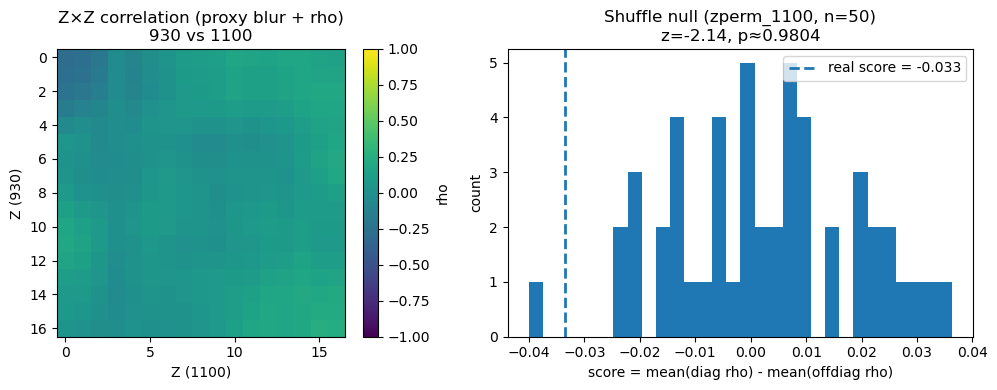

score > 0.2 → PASS
score < 0.1 → FAIL
real_score | zscore | p_empirical = (-0.033489517867565155, -2.141827921098216, 0.9803921568627451)


In [178]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gaussian

# ---------- Core building blocks ----------

def _proxy(img2d, sigma=6.0):
    """Blurred, normalized structural proxy (robust to modality differences)."""
    im = img2d.astype(np.float32)
    im = gaussian(im, sigma=sigma, preserve_range=True)
    im = (im - im.mean()) / (im.std() + 1e-8)
    return im

def z_corr_matrix(stackA, stackB, sigma=6.0):
    """
    stackA, stackB: (Z, Y, X) float/int
    returns: corr_mat (Z, Z) where corr_mat[i,j] = corr(proxyA_i, proxyB_j)
    """
    ZA = stackA.shape[0]
    ZB = stackB.shape[0]
    assert ZA == ZB, "For now this expects same Z count in both stacks."

    A = np.stack([_proxy(stackA[z], sigma=sigma) for z in range(ZA)], axis=0)
    B = np.stack([_proxy(stackB[z], sigma=sigma) for z in range(ZB)], axis=0)

    corr = np.zeros((ZA, ZB), dtype=np.float32)
    for i in range(ZA):
        ai = A[i].ravel()
        ai = (ai - ai.mean()) / (ai.std() + 1e-8)
        for j in range(ZB):
            bj = B[j].ravel()
            bj = (bj - bj.mean()) / (bj.std() + 1e-8)
            corr[i, j] = np.dot(ai, bj) / (ai.size - 1)  # approx Pearson rho
    return corr

def alignment_score_from_corr(corr_mat):
    """
    Single scalar score:
    score = mean(diagonal) - mean(off-diagonal)
    Higher = stronger Z-to-Z matching.
    """
    Z = corr_mat.shape[0]
    diag = np.mean(np.diag(corr_mat))
    off  = np.mean(corr_mat[~np.eye(Z, dtype=bool)])
    return float(diag - off), float(diag), float(off)

# ---------- One-pair QC wrapper ----------

def qc_pair_zmatch(
    stack930, stack1100,
    sigma=6.0,
    n_shuffles=200,
    shuffle="zperm_1100",   # "zperm_1100" or "zperm_930"
    seed=0,
    show=True
):
    """
    stack930, stack1100: (Z,Y,X) typically:
      stack930 = zavg_930[:, ch930, :, :]
      stack1100 = zavg_1100[:, ch1100, :, :]

    shuffle modes:
      - "zperm_1100": shuffle Z order of 1100 stack (breaks diagonal)
      - "zperm_930": shuffle Z order of 930 stack
    """
    rng = np.random.default_rng(seed)

    # Real
    corr_real = z_corr_matrix(stack930, stack1100, sigma=sigma)
    score_real, diag_real, off_real = alignment_score_from_corr(corr_real)

    # Shuffles
    scores_null = np.zeros(n_shuffles, dtype=float)
    for k in range(n_shuffles):
        perm = rng.permutation(stack930.shape[0])
        if shuffle == "zperm_1100":
            corr_k = z_corr_matrix(stack930, stack1100[perm], sigma=sigma)
        elif shuffle == "zperm_930":
            corr_k = z_corr_matrix(stack930[perm], stack1100, sigma=sigma)
        else:
            raise ValueError("shuffle must be 'zperm_1100' or 'zperm_930'")

        scores_null[k], _, _ = alignment_score_from_corr(corr_k)

    # Simple stats
    p_emp = (np.sum(scores_null >= score_real) + 1) / (n_shuffles + 1)  # one-sided
    zscore = (score_real - scores_null.mean()) / (scores_null.std() + 1e-12)

    results = {
        "score_real": score_real,
        "diag_real": diag_real,
        "off_real": off_real,
        "scores_null": scores_null,
        "p_empirical": float(p_emp),
        "zscore": float(zscore),
        "corr_real": corr_real,
    }

    if show:
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))

        im = ax[0].imshow(corr_real, cmap="viridis", vmin=-1, vmax=1)
        ax[0].set_title("Z×Z correlation (proxy blur + rho)\n930 vs 1100")
        ax[0].set_xlabel("Z (1100)")
        ax[0].set_ylabel("Z (930)")
        plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04, label="rho")

        ax[1].hist(scores_null, bins=30)
        ax[1].axvline(score_real, linewidth=2, linestyle="--", label=f"real score = {score_real:.3f}")
        ax[1].set_title(f"Shuffle null ({shuffle}, n={n_shuffles})\n"
                        f"z={zscore:.2f}, p≈{p_emp:.4f}")
        ax[1].set_xlabel("score = mean(diag rho) - mean(offdiag rho)")
        ax[1].set_ylabel("count")
        ax[1].legend()

        plt.tight_layout()
        plt.show()

    return results

res = qc_pair_zmatch(
    gfp_930, tdt_1100,
    sigma=6.0,
    n_shuffles=50,
    shuffle="zperm_1100",
    seed=1,
    show=True
)

print ('score > 0.2 → PASS')
print('score < 0.1 → FAIL')

print(f'real_score | zscore | p_empirical = {res["score_real"], res["zscore"], res["p_empirical"]}')

In [ ]:
# # For debugging

# import tifffile as tiff
# import re

# def dump_scanimage_tags(tif_path, max_chars=6000):
#     with tiff.TiffFile(tif_path) as tf:
#         p0 = tf.pages[0]
#         plast = tf.pages[-1]

#         def show(page, label):
#             print(f"\n===== {label} =====")
#             for tagname in ["Artist", "Software", "ImageDescription"]:
#                 tag = page.tags.get(tagname)
#                 val = tag.value if tag else None
#                 if val is None:
#                     print(f"{tagname}: <None>")
#                     continue
#                 s = str(val)
#                 print(f"{tagname}: len={len(s)}  head:\n{s[:max_chars]}")
#                 # quick “do we have the big SI header?”
#                 hits = re.findall(r"(?m)^(SI\.[^\s=]+)\s*=", s)
#                 if hits:
#                     print(f"Found {len(hits)} SI.* keys, e.g.: {hits[:15]}")
#                 else:
#                     print("Found 0 SI.* keys in this tag.")

#         show(p0, "PAGE 0")
#         show(plast, "LAST PAGE")

# # dump_scanimage_tags("/Users/jcoleman/Documents/--LARGE DATA--/#Khodayari/260113_NK/process1/fileCELL_3x_750nm_00004.tif")
# dump_scanimage_tags(tif_file)


In [ ]:
# FUTURE: Save CSV stuff to NPZ or PKL
#         - read in metadata from NPZ for PKL file